In [1]:
import pandas as pd
import numpy as np

In [2]:

# https://github.com/datasciencedojo/datasets
titanic_dataset_github_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv"

# https://github.com/mwaskom/seaborn-data/tree/master

iris_dataset_github_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/refs/heads/master/iris.csv"

# kaggle
kaggle_link = "https://www.kaggle.com/datasets/yasserh/titanic-dataset/data"

In [3]:
df = pd.read_csv(titanic_dataset_github_url)

In [4]:
df[(df['Sex'] == 'female') & (df['Survived'] == 1)].head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
female_survivors_subset = df[(df['Sex'] == 'female') & (df['Survived'] == 1)][['Name', 'Age']]
female_survivors_subset.head()

In [ ]:
female_survivors_subset_loc = df.loc[(df['Sex'] == 'female') & (df['Survived'] == 1), ['Name', 'Age']]
female_survivors_subset_loc.head()

#  Lock can be faster than the other approach  bcs it is a method and we can do the optimization there 

In [ ]:
df.loc[0, ['Cabin']]

In [ ]:
# Number of survivors

print(len(df[df['Survived'] == 1])) 

# Slicing Rows and Columns

In [ ]:
df.loc[0:4,  ['Name', 'Age']]

In [ ]:
df.head()

In [ ]:
# I want first 3 rows and first 2 columns

# --> numbers for index

df.iloc[0:3, 0:2]

In [ ]:
# First 3 rows and selected columns by index
# --> column 1,3

df.iloc[0:3, [1, 3]]

#  Iloc work with python based integer or indexing. We cannot pass these names in iloc

In [6]:
df.iloc[0:3, [3, 1]]

# [3, 1] => Means we are just mentioning a column in the list 

,Name,Survived
0,"Braund, Mr. Owen Harris",0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1
2,"Heikkinen, Miss. Laina",1


In [ ]:
df.loc[0:2, ['Name', 'Survived']]

#  ['Name', 'Survived'] => in loc we need to mention the name of column 

In [ ]:
df.loc[0:2, ['Survived', 'Name']]

In [ ]:
df.head(3)

![concept behind copy in loc](1.png)

* we will get view in subset in the above equ
* which means we are getting the actual reference 
* if we will do any change in subset we will get change in actual file as well 
* iloc is good then because it will not change the actual data 
* When we will be working on the view  it will give us warning as well 

![Concept behind copy in loc ](2.png)

* but if we get data of 150 columns and another developer swap the columns into it then it is not a good practice to do iloc because the columns has been changed now ,so we have to use the name of the columns and for name of the columns we will use loc
* but for loc we pass the reference which is not good thing at all as it will effect the original data 
* so we will use copy with the loc 

In [ ]:
subset = df[df['Sex'] == 'male'] # might create a view and might create a view 
subset['Age'] = subset['Age'] + 1

print(subset.head(2))
print(df.head(2))


In [ ]:
#  Always create a copy so you will not work on the original reference 
#  You don't want the same reference to be there 
#  Make a new reference
#  So that the original data will never be lost
#  copy will create a new reference


subset = df[df['Sex'] == 'male'].copy()
subset['Age'] += 1
print(subset)

In [ ]:
# iloc --> copy
# loc --> may be view
# df[...] --> may be view


# df  => keep your original dataframe 

# .copy()

In [ ]:
df.head()

In [ ]:
df_by_name = df.set_index('Name')
df_by_name.head()

# Making name as index 

In [ ]:
print(df_by_name.loc['Allen, Mr. William Henry'])

In [ ]:
df_by_name = df_by_name.reset_index()
df_by_name.head()

#  It will revert the index back to pandas handled index 

In [ ]:
df_by_name.reset_index(inplace=True)
df_by_name.head()

#  It will not make a copy , it will do in its own reference 

# inplace=True =>  It is not going to make a new copy, Whatever is the memory reference  it is going to make the changes in that particular reference
#  You will see implace in pytorch also 
#  Where implace = true means (lets say we have a=3, then implace = true means we want to change in the original reference of a  )

In [ ]:
df_by_name = df.set_index('Name')
df_by_name = df_by_name.reset_index() 
df_by_name.head()

# inplace=False (By default) => to see the result we need to save it somewhere bcz it is not going to change in original reference bcz It is a copy

,Name,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,"Braund, Mr. Owen Harris",1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
2,"Heikkinen, Miss. Laina",3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",4,1,1,female,35.0,1,0,113803,53.1000,C123,S
4,"Allen, Mr. William Henry",5,0,3,male,35.0,0,0,373450,8.0500,NaN,S


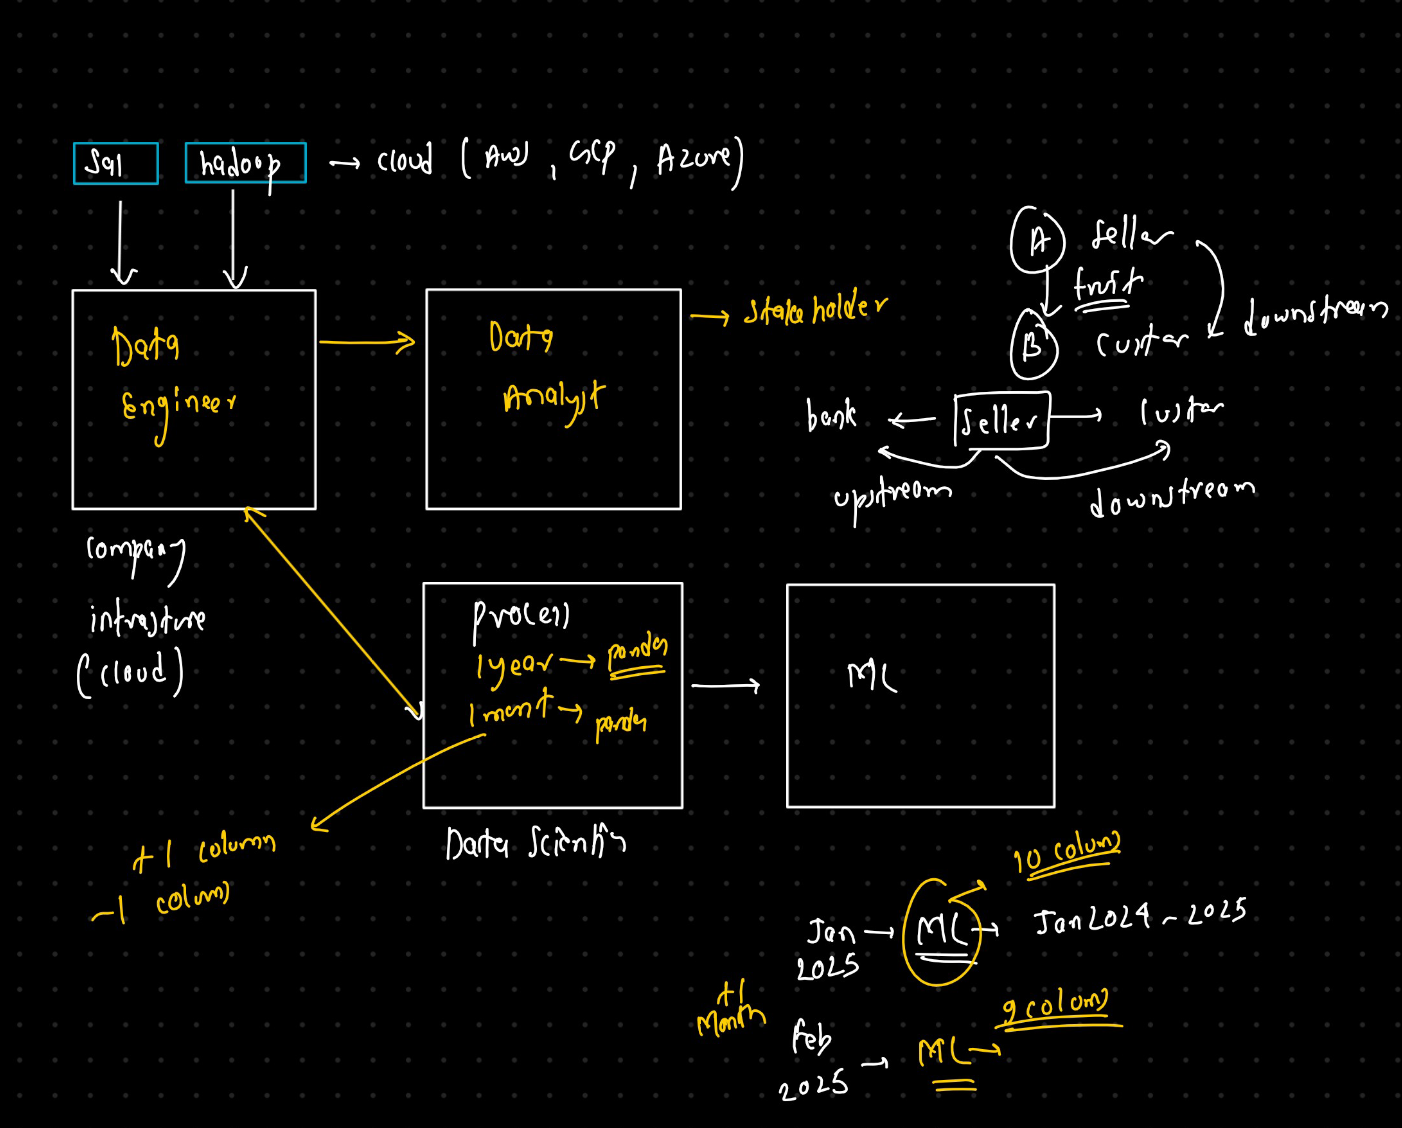

* Data Engineer job is to get data feom different sources that may be on cloud 
* Bring the data to company cloud 
* Process it 
* Send it to Data analyst and then they analyze data and send to stakeholders 
* and also send it to data scientist, who is making an ML model 
* suppose they are making it in jan 2025 the data is from jan 2024 to jan 2025 
* In feb 2025 they want to update their ml model and need current data from data engineers 
* data engineers may reduce one column out of data or add one column out of data using pandas 
* we have to do processing on 9 columns now previously they were 10

# Reindex

In [17]:
sales_jan = pd.DataFrame({
    'Sales': [250, 400, 300]
}, index=['Store_A', 'Store_B', 'Store_C'])

sales_jan

,Sales
Store_A,250
Store_B,400
Store_C,300


In [18]:
sales_feb = pd.DataFrame({
    'Sales': [260, 310]
}, index=['Store_A', 'Store_C'])

sales_feb

,Sales
Store_A,260
Store_C,310


In [19]:
common_index = sales_jan.index

common_index

#  Who has most stable columns

Index(['Store_A', 'Store_B', 'Store_C'], dtype='object')

In [20]:
sales_feb_aligned = sales_feb.reindex(common_index)

In [21]:
sales_feb_aligned

,Sales
Store_A,260.0
Store_B,NaN
Store_C,310.0


In [22]:
sales_diff = sales_feb_aligned['Sales'] - sales_jan['Sales']

sales_diff

#  problem is we cannot perform calculations with NaN

Store_A    10.0
Store_B     NaN
Store_C    10.0
Name: Sales, dtype: float64

In [26]:
# In programming we say null as nothing or nan as nothing 

In [23]:
sales_feb_aligned = sales_feb.reindex(common_index, fill_value=0)

sales_feb_aligned

,Sales
Store_A,260
Store_B,0
Store_C,310


In [24]:
sales_diff = sales_feb_aligned['Sales'] - sales_jan['Sales']

sales_diff

Store_A     10
Store_B   -400
Store_C     10
Name: Sales, dtype: int64

In [25]:
sales_feb_new = pd.DataFrame({
    'Sales': [260, 310, 100]
}, index=['Store_A', 'Store_C', 'Store_D'])

sales_feb_new

,Sales
Store_A,260
Store_C,310
Store_D,100


In [27]:
common_index = list(set(list(sales_jan.index) + list(sales_feb_new.index)))

In [28]:
common_index

['Store_D', 'Store_A', 'Store_B', 'Store_C']

In [29]:
sales_jan_aligned = sales_jan.reindex(common_index, fill_value=0)

sales_jan_aligned

,Sales
Store_D,0
Store_A,250
Store_B,400
Store_C,300


In [30]:
sales_feb_new_aligned = sales_feb_new.reindex(common_index, fill_value=0)

sales_feb_new_aligned

,Sales
Store_D,100
Store_A,260
Store_B,0
Store_C,310


In [31]:
to_check = 'Store_C'
print(sales_feb_new_aligned.loc[to_check])
print(sales_jan_aligned.loc[to_check])

Sales    310
Name: Store_C, dtype: int64
Sales    300
Name: Store_C, dtype: int64


# For column

In [ ]:
source_a = pd.DataFrame({
    'Product': ['Laptop', 'Tablet', 'Phone'],
    'Price': [1000, 500, 800],
    'Stock': [30, 50, 100]
})

source_a

In [ ]:
source_b = pd.DataFrame({
    'Price': [980, 520, 810],
    'Product': ['Laptop', 'Tablet', 'Phone']
})

source_b

In [ ]:
aligned_b = source_b.reindex(columns=source_a.columns, fill_value = 0)

aligned_b

# iteration in pandas

In [33]:
df = pd.DataFrame({
    'Name' : ['heartine', 'gagan', 'gavin'],
    'Age' : [25, 20, 23],
    'City' : ['Delhi', 'Mumbai', 'Chennai'],
})

In [47]:
for row in df.iterrows():
    print(row)

(0, Name    heartine
Age           25
City       Delhi
Name: 0, dtype: object)
(1, Name     gagan
Age         20
City    Mumbai
Name: 1, dtype: object)
(2, Name      gavin
Age          23
City    Chennai
Name: 2, dtype: object)


In [37]:
for index, row in df.iterrows():
    print(index)
    print(row)

0
Name    heartine
Age           25
City       Delhi
Name: 0, dtype: object
1
Name     gagan
Age         20
City    Mumbai
Name: 1, dtype: object
2
Name      gavin
Age          23
City    Chennai
Name: 2, dtype: object


In [34]:
for index, row in df.iterrows():
    print(f"{index}: {row['Name']} lives in {row['City']} and is {row['Age']} years old.")

0: heartine lives in Delhi and is 25 years old.
1: gagan lives in Mumbai and is 20 years old.
2: gavin lives in Chennai and is 23 years old.


In [35]:
for row in df.itertuples():
    print(row)

Pandas(Index=0, Name='heartine', Age=25, City='Delhi')
Pandas(Index=1, Name='gagan', Age=20, City='Mumbai')
Pandas(Index=2, Name='gavin', Age=23, City='Chennai')


In [38]:
for row in df.itertuples():
    print(f"{row.Name} lives in {row.City}, and is {row.Age} years old.", end='\n\n')

heartine lives in Delhi, and is 25 years old.

gagan lives in Mumbai, and is 20 years old.

gavin lives in Chennai, and is 23 years old.



In [39]:
df.columns

Index(['Name', 'Age', 'City'], dtype='object')

In [40]:
for col in df.columns:
    print(f"Column: {col}")

Column: Name
Column: Age
Column: City


In [41]:
for i in df.index:
    print(f"{i}")

0
1
2


In [46]:
for col in df.columns:
    print(col, end='\n\n')
    print(df[col], end='\n\n')

Name

0    heartine
1       gagan
2       gavin
Name: Name, dtype: object

Age

0    25
1    20
2    23
Name: Age, dtype: int64

City

0      Delhi
1     Mumbai
2    Chennai
Name: City, dtype: object



In [43]:
for col in df.columns:
    print(f"Column: {col}")
    print(df[col], end='\n\n')
    print(df[col].values, end='\n\n')

Column: Name
0    heartine
1       gagan
2       gavin
Name: Name, dtype: object

['heartine' 'gagan' 'gavin']

Column: Age
0    25
1    20
2    23
Name: Age, dtype: int64

[25 20 23]

Column: City
0      Delhi
1     Mumbai
2    Chennai
Name: City, dtype: object

['Delhi' 'Mumbai' 'Chennai']



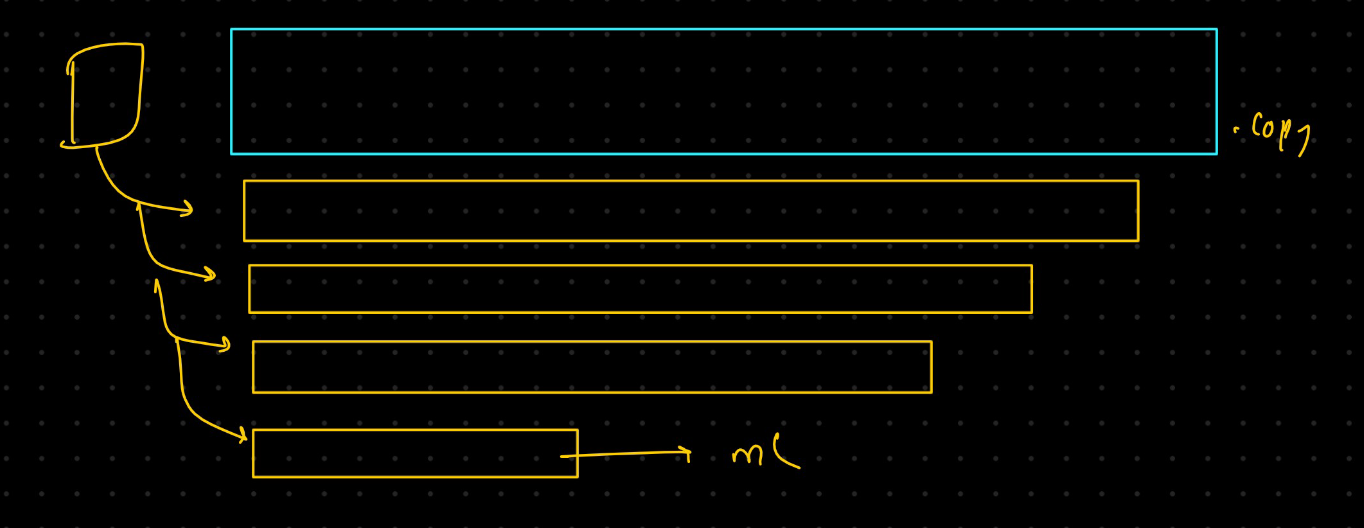

* The idea is that we don't play with the original data ref. We always do the copy and then do some changes on top of it 

# Condition based column creation using custom logic

In [48]:
df.head()

,Name,Age,City
0,heartine,25,Delhi
1,gagan,20,Mumbai
2,gavin,23,Chennai


In [49]:
# if >=30, senior else young

In [50]:
values = []

for idx, row in df.iterrows():
    if row['Age']< 30:
        values.append('young')
    else:
        values.append('senior')

df['Category'] = values

In [ ]:
df

#  This is called feature engineering 
#  With the help of our existing features we create new features 

#  This might be little slow as we use iteration. So we will use vectorize operation 

,Name,Age,City,Category
0,heartine,25,Delhi,young
1,gagan,20,Mumbai,young
2,gavin,23,Chennai,young


In [55]:
# vectorized using apply

In [ ]:
df = pd.DataFrame({
    'Name' : ['heartine', 'gagan', 'gavin'],
    'Age' : [25, 20, 23],
    'City' : ['Delhi', 'Mumbai', 'Chennai'],
})


In [ ]:
# Faster as compared to iter rows 
df['Categories'] = df['Age'].apply(lambda age : 'young' if age < 30 else 'senior')

In [ ]:
df

In [ ]:
# Which  one is the faster of the 3 below 


#  apply is the fastest 

# iterrows < itertuples < apply

# Sort

In [56]:
# 1.  sort_values (Sort using values ) --> means data values 
# 2. sort_index (and sort using index ) --> means rows / column

In [57]:
titanic_dataset_github_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv"

df = pd.read_csv(titanic_dataset_github_url)

In [58]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [59]:
#  I want this dataframe to be sorted by age 


sorted_df = df.sort_values(by='Age')
sorted_df[['Name', 'Age']].head(100)

,Name,Age
803,"Thomas, Master. Assad Alexander",0.42
755,"Hamalainen, Master. Viljo",0.67
644,"Baclini, Miss. Eugenie",0.75
469,"Baclini, Miss. Helene Barbara",0.75
78,"Caldwell, Master. Alden Gates",0.83
...,...,...
764,"Eklund, Mr. Hans Linus",16.00
504,"Maioni, Miss. Roberta",16.00
746,"Abbott, Mr. Rossmore Edward",16.00
156,"Gilnagh, Miss. Katherine ""Katie""",16.00


In [60]:
sorted_df[['Name', 'Age']].tail(5)

,Name,Age
859,"Razi, Mr. Raihed",NaN
863,"Sage, Miss. Dorothy Edith ""Dolly""",NaN
868,"van Melkebeke, Mr. Philemon",NaN
878,"Laleff, Mr. Kristo",NaN
888,"Johnston, Miss. Catherine Helen ""Carrie""",NaN


In [ ]:
sorted_df.loc[0:100, ['Name', 'Age']]

#  It is giving everything from 0 and hundred

,Name,Age
0,"Braund, Mr. Owen Harris",22.0
212,"Perkin, Mr. John Henry",22.0
151,"Pears, Mrs. Thomas (Edith Wearne)",22.0
708,"Cleaver, Miss. Alice",22.0
141,"Nysten, Miss. Anna Sofia",22.0
...,...,...
399,"Trout, Mrs. William H (Jessie L)",28.0
403,"Hakkarainen, Mr. Pekka Pietari",28.0
169,"Ling, Mr. Lee",28.0
430,"Bjornstrom-Steffansson, Mr. Mauritz Hakan",28.0


* Data Scientist are not who are creating the data 
* We need to process the data accoeding to our need 
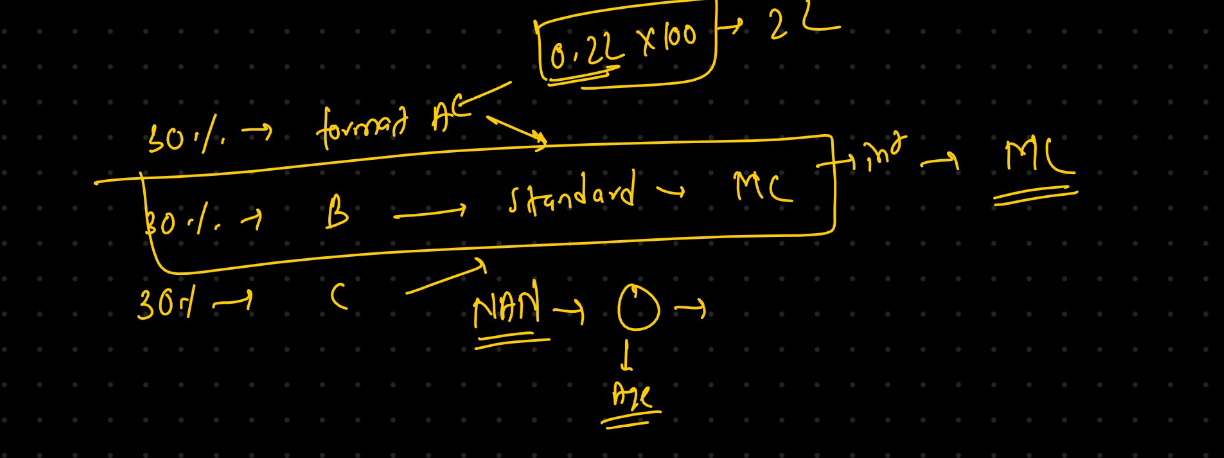
* all of data is in different formats. We need to standardise the data
* And then machine learning techniques  will apply 

In [62]:
print(df['Age'].dtype)

float64


In [ ]:
df['Age'] = df['Age'].astype('int64')

#  We need to fix that NaN before converting to int64 

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [64]:
df['Age'] = df['Age'].fillna(0).astype('int64')

In [65]:
print(df['Age'].dtype)

int64


In [66]:
sorted_df = df.sort_values(by='Age')
print(sorted_df[['Name', 'Age']].tail(20))

                                          Name  Age
625                      Sutton, Mr. Frederick   61
829  Stone, Mrs. George Nelson (Martha Evelyn)   62
555                         Wright, Mr. George   62
252                  Stead, Mr. William Thomas   62
570                         Harris, Mr. George   62
483                     Turkula, Mrs. (Hedwig)   63
275          Andrews, Miss. Kornelia Theodosia   63
438                          Fortune, Mr. Mark   64
545               Nicholson, Mr. Arthur Ernest   64
456                  Millet, Mr. Francis Davis   65
280                           Duane, Mr. Frank   65
54              Ostby, Mr. Engelhart Cornelius   65
33                       Wheadon, Mr. Edward H   66
672                Mitchell, Mr. Henry Michael   70
745               Crosby, Capt. Edward Gifford   70
116                       Connors, Mr. Patrick   70
493                    Artagaveytia, Mr. Ramon   71
96                   Goldschmidt, Mr. George B   71
851         

In [67]:
print(sorted_df[['Name', 'Age']].head(20))

                                       Name  Age
667              Rommetvedt, Mr. Knud Paust    0
128                       Peter, Miss. Anna    0
533  Peter, Mrs. Catherine (Catherine Rizk)    0
284              Smith, Mr. Richard William    0
538                Risien, Mr. Samuel Beard    0
277             Parkes, Mr. Francis "Frank"    0
274              Healy, Miss. Hanora "Nora"    0
740             Hawksford, Mr. Walter James    0
739                      Nankoff, Mr. Minko    0
547              Padro y Manent, Mr. Julian    0
531                       Toufik, Mr. Nakli    0
738                      Ivanoff, Mr. Kanio    0
732                    Knight, Mr. Robert J    0
140           Boulos, Mrs. Joseph (Sultana)    0
552                    O'Brien, Mr. Timothy    0
727                Mannion, Miss. Margareth    0
264                      Henry, Miss. Delia    0
557                     Robbins, Mr. Victor    0
560                Morrow, Mr. Thomas Rowan    0
260                 

In [ ]:
# sort by multiple columns

In [68]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NaN,S


In [69]:
df_sorted = df.sort_values(by=['Pclass', 'Fare']) # ascending order

In [70]:
df_sorted.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
263,264,0,1,"Harrison, Mr. William",male,40,0,0,112059,0.0,B94,S
633,634,0,1,"Parr, Mr. William Henry Marsh",male,0,0,0,112052,0.0,NaN,S
806,807,0,1,"Andrews, Mr. Thomas Jr",male,39,0,0,112050,0.0,A36,S
815,816,0,1,"Fry, Mr. Richard",male,0,0,0,112058,0.0,B102,S
822,823,0,1,"Reuchlin, Jonkheer. John George",male,38,0,0,19972,0.0,NaN,S


In [71]:
#  We want Pclass to go in asending order and Fare to go in desending order 
df_sorted = df.sort_values(by=['Pclass', 'Fare'], ascending=[True, False]) # ascending order

In [72]:
df_sorted.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35,0,0,PC 17755,512.3292,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35,0,0,PC 17755,512.3292,B101,C
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19,3,2,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23,3,2,19950,263.0000,C23 C25 C27,S


In [ ]:
#  If this is the dataframe we like after cleaning  we can convert this dataframe to csv also  

df_sorted.to_csv("a.csv")

In [74]:
# sort_index

In [73]:
# axis = 0 # means rows
# axis = 1 # means column

In [75]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NaN,S


In [77]:
df_sort_2 = df.set_index('PassengerId')

In [80]:
df_sort_2

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,0,1,2,W./C. 6607,23.4500,NaN,S


In [ ]:
df_sorted_by_index = df_sort_2.sort_index()

#  By default when we use the sort index the axis is equal to zero 

In [82]:
df_sorted_by_index.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NaN,S


In [ ]:
df_sorted_by_index = df_sort_2.sort_index(axis=0, ascending=False)
df_sorted_by_index.head()

In [ ]:
# df_sort_2.sort_index(axis=0, ascending=False,inplace=True)

#  We don't need to store it in new variable bcz it will make the changes in orginal reference 

# sorting columns alphabets

In [89]:
df_sorted_cols = df.sort_index(axis=1)

In [90]:
df_sorted_cols.head()

,Age,Cabin,Embarked,Fare,Name,Parch,PassengerId,Pclass,Sex,SibSp,Survived,Ticket
0,22.0,NaN,S,7.2500,"Braund, Mr. Owen Harris",0,1,3,male,1,0,A/5 21171
1,38.0,C85,C,71.2833,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,2,1,female,1,1,PC 17599
2,26.0,NaN,S,7.9250,"Heikkinen, Miss. Laina",0,3,3,female,0,1,STON/O2. 3101282
3,35.0,C123,S,53.1000,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,4,1,female,1,1,113803
4,35.0,NaN,S,8.0500,"Allen, Mr. William Henry",0,5,3,male,0,0,373450


# Changing Column order in Pandas (axis 1 values  are the heading itself, Hence Sorting column one is what axis=1 is)

In [83]:
titanic_dataset_github_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv"

df = pd.read_csv(titanic_dataset_github_url)

In [84]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [85]:
new_order = ['Name', 'Sex', 'Age', 'Pclass', 'Fare', 'Survived']

In [86]:
df_reordered = df[new_order]
print(df_reordered.head())

                                                Name     Sex   Age  Pclass  \
0                            Braund, Mr. Owen Harris    male  22.0       3   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0       1   
2                             Heikkinen, Miss. Laina  female  26.0       3   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0       1   
4                           Allen, Mr. William Henry    male  35.0       3   

      Fare  Survived  
0   7.2500         0  
1  71.2833         1  
2   7.9250         1  
3  53.1000         1  
4   8.0500         0  


In [87]:
sorted(df.columns)

['Age',
 'Cabin',
 'Embarked',
 'Fare',
 'Name',
 'Parch',
 'PassengerId',
 'Pclass',
 'Sex',
 'SibSp',
 'Survived',
 'Ticket']

In [88]:
df_reordered = df[sorted(df.columns)]

df_reordered.head()

,Age,Cabin,Embarked,Fare,Name,Parch,PassengerId,Pclass,Sex,SibSp,Survived,Ticket
0,22.0,NaN,S,7.2500,"Braund, Mr. Owen Harris",0,1,3,male,1,0,A/5 21171
1,38.0,C85,C,71.2833,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,2,1,female,1,1,PC 17599
2,26.0,NaN,S,7.9250,"Heikkinen, Miss. Laina",0,3,3,female,0,1,STON/O2. 3101282
3,35.0,C123,S,53.1000,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,4,1,female,1,1,113803
4,35.0,NaN,S,8.0500,"Allen, Mr. William Henry",0,5,3,male,0,0,373450


# working with text data in pandas

In [91]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [92]:
print(df[['Name', 'Sex', 'Cabin']].head(3))

                                                Name     Sex Cabin
0                            Braund, Mr. Owen Harris    male   NaN
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female   C85
2                             Heikkinen, Miss. Laina  female   NaN


In [93]:
df['Name'].str.lower()

0                                braund, mr. owen harris
1      cumings, mrs. john bradley (florence briggs th...
2                                 heikkinen, miss. laina
3           futrelle, mrs. jacques heath (lily may peel)
4                               allen, mr. william henry
                             ...                        
886                                montvila, rev. juozas
887                         graham, miss. margaret edith
888             johnston, miss. catherine helen "carrie"
889                                behr, mr. karl howell
890                                  dooley, mr. patrick
Name: Name, Length: 891, dtype: object

In [94]:
df['Name'].str.upper()

0                                BRAUND, MR. OWEN HARRIS
1      CUMINGS, MRS. JOHN BRADLEY (FLORENCE BRIGGS TH...
2                                 HEIKKINEN, MISS. LAINA
3           FUTRELLE, MRS. JACQUES HEATH (LILY MAY PEEL)
4                               ALLEN, MR. WILLIAM HENRY
                             ...                        
886                                MONTVILA, REV. JUOZAS
887                         GRAHAM, MISS. MARGARET EDITH
888             JOHNSTON, MISS. CATHERINE HELEN "CARRIE"
889                                BEHR, MR. KARL HOWELL
890                                  DOOLEY, MR. PATRICK
Name: Name, Length: 891, dtype: object

In [95]:
df['Name'].str.capitalize()

0                                Braund, mr. owen harris
1      Cumings, mrs. john bradley (florence briggs th...
2                                 Heikkinen, miss. laina
3           Futrelle, mrs. jacques heath (lily may peel)
4                               Allen, mr. william henry
                             ...                        
886                                Montvila, rev. juozas
887                         Graham, miss. margaret edith
888             Johnston, miss. catherine helen "carrie"
889                                Behr, mr. karl howell
890                                  Dooley, mr. patrick
Name: Name, Length: 891, dtype: object

In [96]:
df['Name'].str.len()

0      23
1      51
2      22
3      44
4      24
       ..
886    21
887    28
888    40
889    21
890    19
Name: Name, Length: 891, dtype: int64

In [97]:
df['Name'].str.replace("Mr.", "Sir", regex=False).head()

0                              Braund, Sir Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Sir William Henry
Name: Name, dtype: object

In [ ]:
# p.s -> replace every thing with brackets around it

# (abc)
# (abc abc)
# (Abc dasdass dsds dsdsw dsds dswds)
# pattern-1 , start - (, words of any length, end - )
# pattern-2 , start - (, end - ), words of any length, 

In [ ]:
df['Name'].str.replace(r"\(.*\)", "", regex=True).head()

#  r"pattern of regex"
#  Here 
#  \ => means it will match the exact opening  => \
#  Exact opening is starting brancket => \(
# To mention worda of any length we write .* (. means  any character , * means zero or more )=>\(.*
#  for closing => \(.*\)


#  No boody remember it. You can copy from google or stack for phone , gmail etc 

0          Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley 
2           Heikkinen, Miss. Laina
3    Futrelle, Mrs. Jacques Heath 
4         Allen, Mr. William Henry
Name: Name, dtype: object

* using reges you can write certain kind of code 
* where you write certain kind of code where you mention the pattern in some coding language and it will be able to check on the basisi of pattern you mentioned 
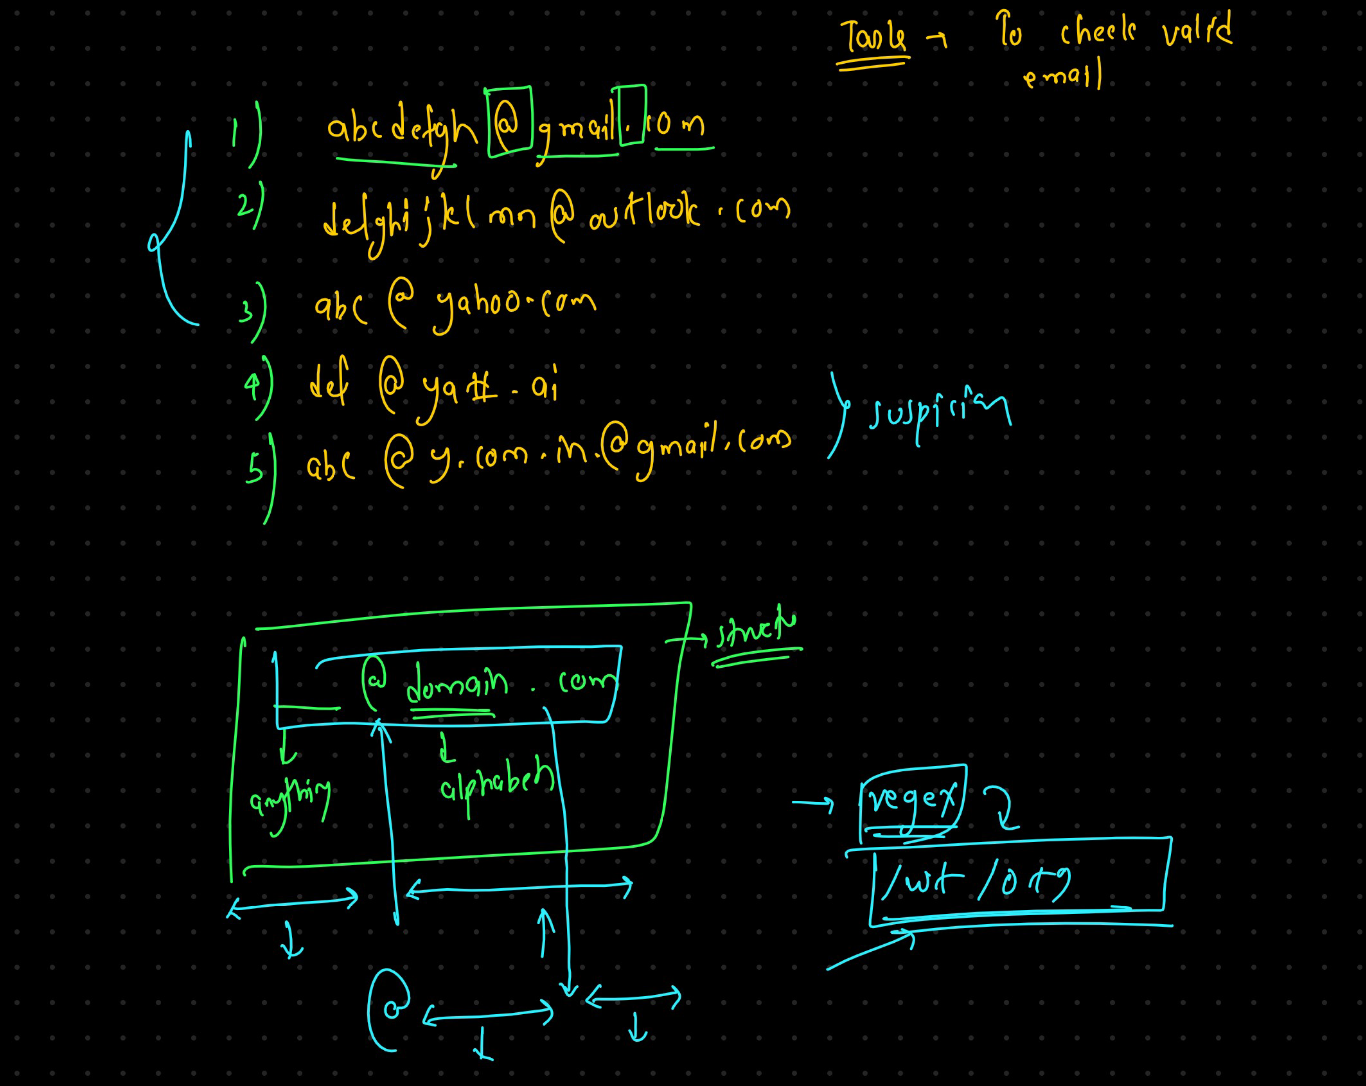

# Extract with Regex

In [99]:
df['Title'] = df['Name'].str.extract(r'(\(.*\))', expand=False)

# like vs code press control + F for search and press .* and then write expression 
# expand=True. => It will give you the series 

#  expand=False. => It will give you the dataframe 


In [100]:
df['Title']

0                           NaN
1      (Florence Briggs Thayer)
2                           NaN
3               (Lily May Peel)
4                           NaN
                 ...           
886                         NaN
887                         NaN
888                         NaN
889                         NaN
890                         NaN
Name: Title, Length: 891, dtype: object

In [103]:
df['Name'].str.extract(r'(\(.*\))', expand=True)

,0
0,NaN
1,(Florence Briggs Thayer)
2,NaN
3,(Lily May Peel)
4,NaN
...,...
886,NaN
887,NaN
888,NaN
889,NaN


In [101]:
type(df['Name'].str.extract(r'(\(.*\))', expand=True))


pandas.core.frame.DataFrame

In [102]:
type(df['Name'].str.extract(r'(\(.*\))', expand=False))

pandas.core.series.Series

# Split and Access Elements

In [104]:
df['Name'][0]

'Braund, Mr. Owen Harris'

In [105]:
df['Name'].str.split(",", expand=True)

,0,1
0,Braund,Mr. Owen Harris
1,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,Heikkinen,Miss. Laina
3,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,Allen,Mr. William Henry
...,...,...
886,Montvila,Rev. Juozas
887,Graham,Miss. Margaret Edith
888,Johnston,"Miss. Catherine Helen ""Carrie"""
889,Behr,Mr. Karl Howell


In [106]:
df['Name'].str.split(",", expand=True)[0]

0         Braund
1        Cumings
2      Heikkinen
3       Futrelle
4          Allen
         ...    
886     Montvila
887       Graham
888     Johnston
889         Behr
890       Dooley
Name: 0, Length: 891, dtype: object

In [107]:
df['Name'].str.split(",", expand=False)

0                             [Braund,  Mr. Owen Harris]
1      [Cumings,  Mrs. John Bradley (Florence Briggs ...
2                              [Heikkinen,  Miss. Laina]
3        [Futrelle,  Mrs. Jacques Heath (Lily May Peel)]
4                            [Allen,  Mr. William Henry]
                             ...                        
886                             [Montvila,  Rev. Juozas]
887                      [Graham,  Miss. Margaret Edith]
888          [Johnston,  Miss. Catherine Helen "Carrie"]
889                             [Behr,  Mr. Karl Howell]
890                               [Dooley,  Mr. Patrick]
Name: Name, Length: 891, dtype: object

In [109]:
df['Name'].str.split(",", expand=False)[0]

['Braund', ' Mr. Owen Harris']

In [ ]:
df['Name'].str.split(expand=True)[0] #When don't mention anything it will check  all white space

0         Braund,
1        Cumings,
2      Heikkinen,
3       Futrelle,
4          Allen,
          ...    
886     Montvila,
887       Graham,
888     Johnston,
889         Behr,
890       Dooley,
Name: 0, Length: 891, dtype: object

In [111]:
df['Name'].str.strip() 

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

In [112]:
df['Name'].str.lstrip()

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

In [113]:
df['Name'].str.rstrip()

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

# Find position of substring

In [ ]:
df['Name'].str.find("Mr")

#  Want to find the index where Mr is starting 
#  Mr is not present in particular string that is why it is -1

0       8
1       9
2      -1
3      10
4       7
       ..
886    -1
887    -1
888    -1
889     6
890     8
Name: Name, Length: 891, dtype: int64

In [ ]:
# Count passengers with “Miss” in their name
count = df['Name'].str.contains("Miss").sum()
print("Number of 'Miss':", count)

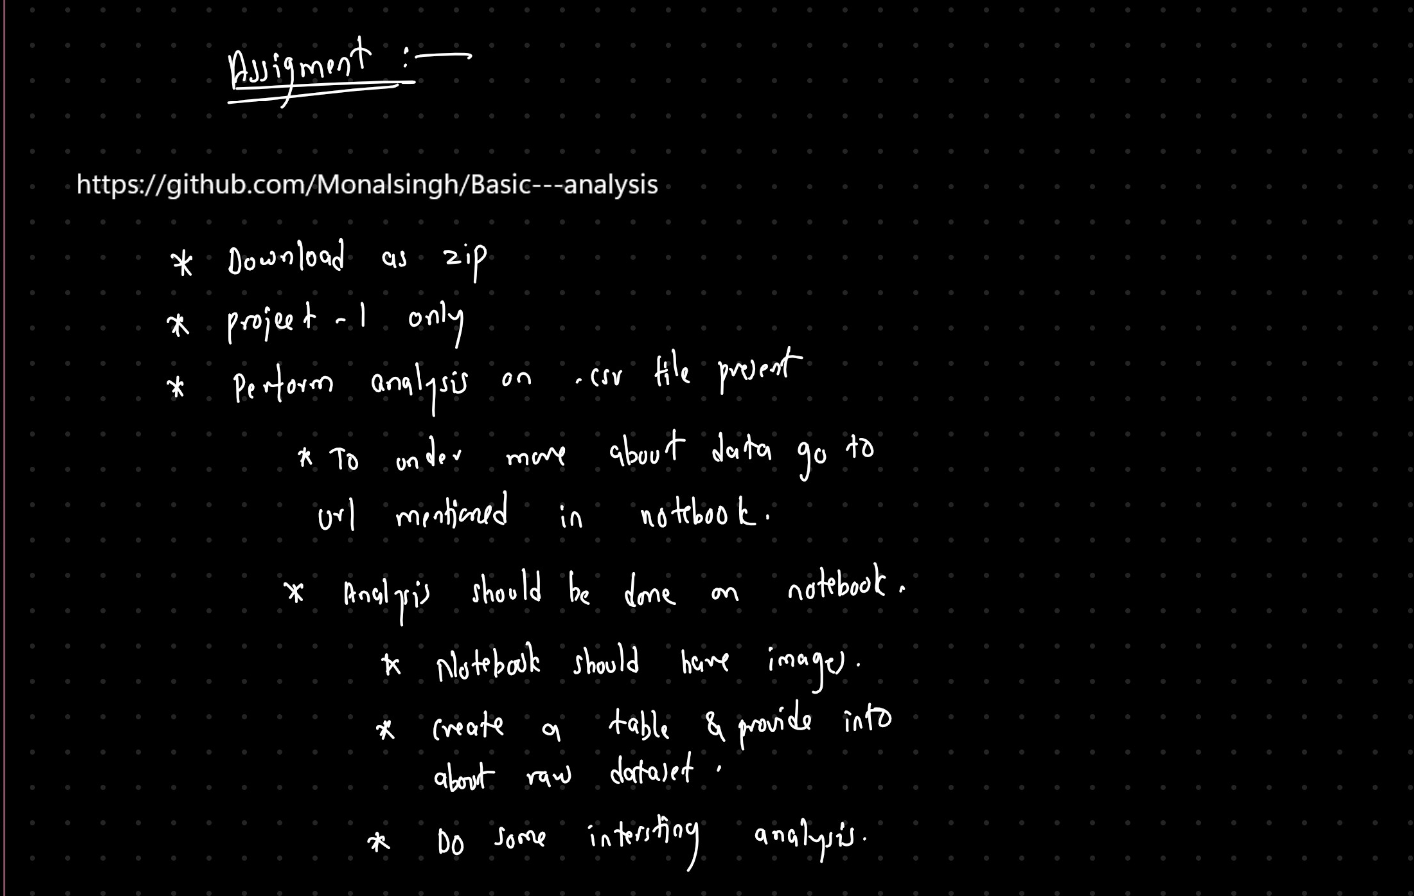